# Imports

In [76]:
import pandas as pd
import numpy as np

# Get and Format Data

In [77]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [78]:
sweden_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/sweden_train_{year}.csv"), year) for year in range(2022, 2025)]
sweden_train = pd.concat(sweden_train_sets, axis=0)

quebec_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/quebec_train_{year}.csv"), year) for year in range(2022, 2025)]
quebec_train = pd.concat(quebec_train_sets, axis=0)

siberia_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/siberia_train_{year}.csv"), year) for year in range(2022, 2025)]
siberia_train = pd.concat(siberia_train_sets, axis=0)

train_set = pd.concat([sweden_train, quebec_train, siberia_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
5962     2_2962_0       -0.158587  0.154712        -0.173811   0.011587   
3139      2_139_0        0.027264  0.339333         0.037461   0.286588   
871      1_3871_0       -0.147542  0.243645        -0.201909   0.178149   
577      1_3577_0       -0.244020  0.233076        -0.298631   0.156315   
1750     1_4750_0        0.063800  0.264304         0.016623   0.183184   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
5962        -0.116581   0.261830            1145.0     10432.0   
3139        -0.060768   0.275967            2005.0     10261.0   
871          0.038856   0.241341           -4868.0      8805.0   
577          0.274795   0.234107          -26312.0     10078.0   
1750         0.107912   0.318761           -1474.5      8461.5   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
5962           -2762.0  ...   0.378411      9287.0     20594.5     14152.5

In [79]:
print(len(train_set))

54000


In [80]:
all_features = train_set.columns.drop(['year', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [81]:
from sklearn.model_selection import train_test_split

X = train_set[recent_features]
y = train_set['class']


# Evaluate Model on Training Data via Nested-CV

In [47]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


In [49]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [50]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [51]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X, 
    y, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [52]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 1 - Inner Mean Test Score:  0.984563
Outer Fold 1 - Inner Test Score STD:  0.003713
Outer Fold 1 - Inner Mean Train Score: 0.998120
Outer Fold 1 - Inner Train Score STD:  0.003713
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 2 - Inner Mean Test Score:  0.997822
Outer Fold 2 - Inner Test Score STD:  0.001160
Outer Fold 2 - Inner Mean Train Score: 0.999145
Outer Fold 2 - Inner Train Score STD:  0.001160

Overall Metrics
Mean Test f1: 0.99940654
Mean Test Precision: 0.99983039
Mean Test Recall: 0.99898305
Mean Train f1: 0.99940654
Mean Train Precision:

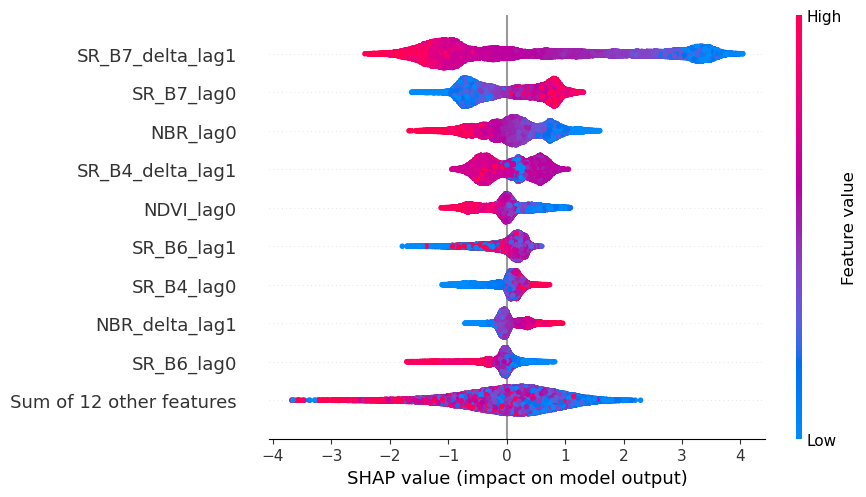

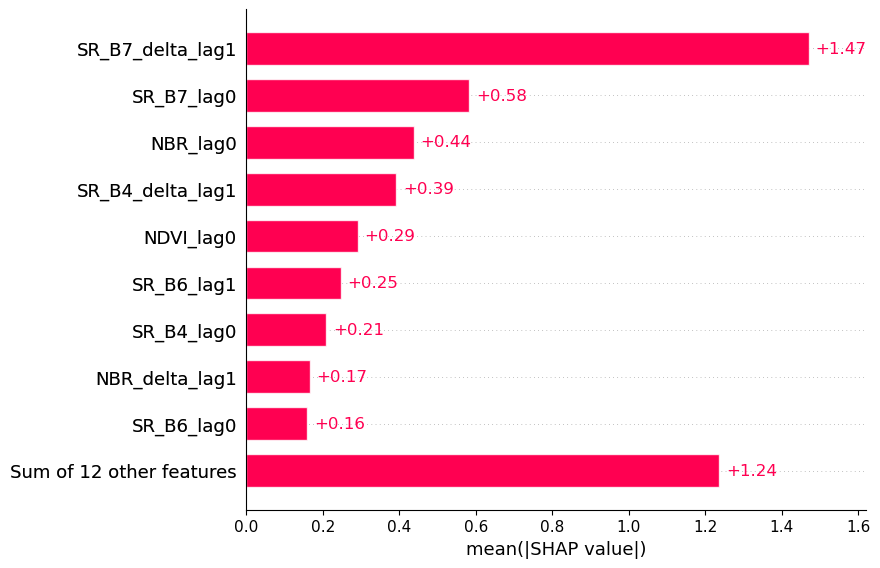

In [53]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X, y)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X),
    columns=recent_features,
    index=X.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


# Train Model

In [87]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [88]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [89]:
xgboost_param_grid = {
    'max_depth': Integer(3, 5),
    'min_child_weight': Integer (1, 200),
    'subsample': Real(0.7, 1),
    'colsample_bylevel': Real(0.5, 1),
    'colsample_bynode': Real(0.5, 1),
    'reg_lambda': Real(0, 10),
    'reg_alpha': Real(0, 10)
}

In [90]:
stage_1_model = XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist')

tuner = BayesSearchCV(
    estimator=stage_1_model,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [91]:
tuner.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,search_spaces,"{'colsample_bylevel': Real(low=0.5,...m='normalize'), 'colsample_bynode': Real(low=0.5,...m='normalize'), 'max_depth': Integer(low=3...m='normalize'), 'min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [92]:
print(tuner.best_params_)
params = tuner.best_params_

OrderedDict({'colsample_bylevel': 1.0, 'colsample_bynode': 1.0, 'max_depth': 5, 'min_child_weight': 1, 'reg_alpha': 10.0, 'reg_lambda': 0.0, 'subsample': 1.0})


In [99]:
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [100]:

stage_2_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69260
[1]	validation_0-logloss:0.69205
[2]	validation_0-logloss:0.69151
[3]	validation_0-logloss:0.69096
[4]	validation_0-logloss:0.69042
[5]	validation_0-logloss:0.68988
[6]	validation_0-logloss:0.68934
[7]	validation_0-logloss:0.68880
[8]	validation_0-logloss:0.68826
[9]	validation_0-logloss:0.68772
[10]	validation_0-logloss:0.68718
[11]	validation_0-logloss:0.68665
[12]	validation_0-logloss:0.68611
[13]	validation_0-logloss:0.68558
[14]	validation_0-logloss:0.68504
[15]	validation_0-logloss:0.68451
[16]	validation_0-logloss:0.68398
[17]	validation_0-logloss:0.68345
[18]	validation_0-logloss:0.68292
[19]	validation_0-logloss:0.68240
[20]	validation_0-logloss:0.68187
[21]	validation_0-logloss:0.68134
[22]	validation_0-logloss:0.68082
[23]	validation_0-logloss:0.68030
[24]	validation_0-logloss:0.67977
[25]	validation_0-logloss:0.67925
[26]	validation_0-logloss:0.67873
[27]	validation_0-logloss:0.67821
[28]	validation_0-logloss:0.67770
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,1.0
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method="

In [101]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6433673921172266


In [102]:
final_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist')
final_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,1.0
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [103]:
print(f1_score(y, final_model.predict(X)))

0.8474435151194035


In [ ]:
import shap
explainer = shap.Explainer(final_model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_model.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


TypeError: 'XGBClassifier' object is not subscriptable

In [ ]:
print(len(X))

54000


# Test On Holdout Set From the Same Region

In [104]:
sweden_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/sweden_test_2025.csv"), 2025)
quebec_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/boreal/quebec_test_2025.csv"), 2025)
siberia_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/boreal/siberia_test_2025.csv"), 2025)

print(len(sweden_test))
print(len(quebec_test))
print(len(siberia_test))


6000
6000
6000


In [105]:
X_test_sweden = sweden_test[recent_features]
y_test_sweden = sweden_test['class']
X_test_quebec = quebec_test[recent_features]
y_test_quebec = quebec_test['class']
X_test_siberia = siberia_test[recent_features]
y_test_siberia = siberia_test['class']
print(y_test_quebec.value_counts())

class
0    3000
1    3000
Name: count, dtype: int64


In [106]:
from sklearn.metrics import precision_score, recall_score

print("sweden Test")
y_test_sweden_pred = final_model.predict(X_test_sweden)
print(f"f1: {f1_score(y_test_sweden, y_test_sweden_pred)}")
print(f"precision: {precision_score(y_test_sweden, y_test_sweden_pred)}")
print(f"recall: {recall_score(y_test_sweden, y_test_sweden_pred)}")

print("siberia Test")
y_test_siberia_pred = final_model.predict(X_test_siberia)
print(f"f1: {f1_score(y_test_siberia, y_test_siberia_pred)}")
print(f"precision: {precision_score(y_test_siberia, y_test_siberia_pred)}")
print(f"recall: {recall_score(y_test_siberia, y_test_siberia_pred)}")

print("quebec Test")
y_test_quebec_pred = final_model.predict(X_test_quebec)
print(f"f1: {f1_score(y_test_quebec, y_test_quebec_pred)}")
print(f"precision: {precision_score(y_test_quebec, y_test_quebec_pred)}")
print(f"recall: {recall_score(y_test_quebec, y_test_quebec_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_sweden, X_test_siberia, X_test_quebec])
y_test = pd.concat([y_test_sweden, y_test_siberia, y_test_quebec])
y_test_pred = final_model.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

sweden Test
f1: 0.9080345285524568
precision: 0.904431216931217
recall: 0.9116666666666666
siberia Test
f1: 0.8678551736813086
precision: 0.9672265464973372
recall: 0.787
quebec Test
f1: 0.7849885283513602
precision: 0.7720825274016764
recall: 0.7983333333333333
All Together Test
f1: 0.8528490920475892
precision: 0.8744017742500292
recall: 0.8323333333333334


# Test on New Regions

In [107]:
alaska_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/alaska_test_2025.csv"), 2025)

In [108]:
X_test_alaska = alaska_test[recent_features]
y_test_alaska = alaska_test['class']
print(y_test_alaska.value_counts())

class
0    3000
1    3000
Name: count, dtype: int64


In [109]:
print("alaska Test")
y_test_alaska_pred = final_model.predict(X_test_alaska)
print(f"f1: {f1_score(y_test_alaska, y_test_alaska_pred)}")
print(f"precision: {precision_score(y_test_alaska, y_test_alaska_pred)}")
print(f"recall: {recall_score(y_test_alaska, y_test_alaska_pred)}")


alaska Test
f1: 0.7577567932164193
precision: 0.8981269986295112
recall: 0.6553333333333333


In [110]:
print(list(final_model.predict_proba(X_test_sweden)))

[array([0.5415138 , 0.45848623], dtype=float32), array([0.5407035 , 0.45929652], dtype=float32), array([0.5415138 , 0.45848623], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.4628966, 0.5371034], dtype=float32), array([0.46251422, 0.5374858 ], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.53580034, 0.46419963], dtype=float32), array([0.5415138 , 0.45848623], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.46891338, 0.5310866 ], dtype=float32), array([0.4636091, 0.5363909], dtype=float32), array([0.5061399 , 0.49386016], dtype=float32), array([0.45465815, 0.54534185], dtype=float32), array([0.50534505, 0.49465495], dtype=float32), array([0.5227481 , 0.47725186], dtype=float32), array([0.53580034, 0.46419963], dtype=float32), array([0.4946494, 0.5053506], dtype=float32), array([0.45465815, 0.54534185], dtype=float32

In [111]:
final_model.save_model("../app/ml_models/xgb_boreal.json")

boreal model succeeds, though not quite as good on the alaska...